In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *
from warpPlot import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 128
dim = 2
L = 2 * np.pi
n_h = 4
targetDt = 0.001

gamma = 5/3
rho0 = 1
nu_visc = 0.0005
freeSurface = False

extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'nu_visc': nu_visc,
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros(dim, device=device, dtype=dtype)
domain.max = torch.ones(dim, device=device, dtype=dtype) * 2 * np.pi
interiorDomain = domain

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = IncompressibleSPHScheme.divergenceFree
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.surfaceDetectionConfig.active = freeSurface


In [4]:

fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)
regions = []

regions.append(buildRegion(config, schemeConfig, fluid_sdf, RegionType.Fluid, initialConditions = {}))

for region in regions:
    region = filterRegion(region, regions)

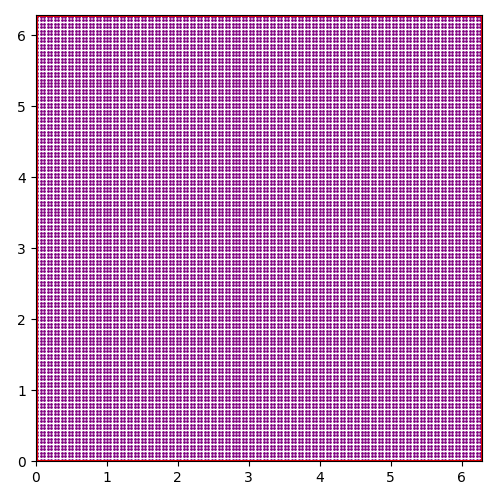

In [5]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [6]:
compressibleSystem = setupBasicWeaklyCompressibleInitialState(nx, config, schemeConfig, SimulationState, SimulationSystem)
densities = computeDensities(compressibleSystem.state, config, schemeConfig, None)
print(f"Initial density stats: mean: {densities.mean().cpu().item():.6g}, min: {densities.min().cpu().item():.6g}, max: {densities.max().cpu().item():.6g}")
compressibleSystem.state.masses = compressibleSystem.state.masses / densities.mean() * rho0
densities = computeDensities(compressibleSystem.state, config, schemeConfig, None)
print(f"After correction density stats: mean: {densities.mean().cpu().item():.6g}, min: {densities.min().cpu().item():.6g}, max: {densities.max().cpu().item():.6g}")

# compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 32, jitterAmount = 1.0)


k = 2
u_mag = 1
k_ = k

ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv *  compressibleSystem.state.positions[:,1] + phaseShift_y)
compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * compressibleSystem.state.positions[:,1] + phaseShift_y)



schemeConfig.fluid.fixedSoundSpeed, config.dt = setupWeaklyCompressibleTimestep(config, schemeConfig, compressibleSystem, targetDt, verbose = True)
print(f"Computed timestep: {config.dt:.6g}, target timestep: {targetDt:.6g}, diff: {abs(config.dt - targetDt):.6g}")

Module sphWarpCore.radiusSearch.wp_compactHash 55d44f3 load on device 'cuda:0' took 2.72 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 3761b33 load on device 'cuda:0' took 3.72 ms  (cached)
Initial density stats: mean: 1.00042, min: 1.00041, max: 1.00042
After correction density stats: mean: 1, min: 0.999993, max: 1
Computed c0: 27.129610061645508, target c0: 10.0, diff: 17.129610061645508
Computed dt: 0.0010000000474974513, target dt: 0.001, diff: 0.0
Max velocity: 0.9993979334831238, CFL: 0.020359566435217857, Max Mach: 0.036837901920080185
Computed timestep: 0.001, target timestep: 0.001, diff: 0


In [7]:
ke0 = compressibleSystem.state.masses * torch.linalg.norm(compressibleSystem.state.velocities, dim=1)**2 * 0.5
m_total = compressibleSystem.state.masses.sum().cpu().item()
# kineticEnergy = np.array([ke.cpu().item() for ke in kes]).sum()

domainL = config.domain.max[0].cpu().item() - config.domain.min[0].cpu().item()
Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2
print(f"Theoretical initial kinetic energy: {Ek0_theoretical:.6g}")
print(f"Initial kinetic energy from simulation: {ke0.sum().cpu().item():.6g}")
print(f'Difference: {abs(Ek0_theoretical - ke0.sum().cpu().item()):.6g}')

Theoretical initial kinetic energy: 9.8696
Initial kinetic energy from simulation: 9.8655
Difference: 0.00410545


In [8]:
runningState = compressibleSystem.initializeNewState()

caseName = 'tgv_incompressible'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
# exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    # 'frame_num': 0,
# }, **extraData))

In [9]:
from dfsph import *

In [10]:
config.dt = 1e-3
runningState = compressibleSystem.initializeNewState()
# runningState.state.positions = shuffleParticles(runningState.state, config, schemeConfig, 0, jitterAmount = 0.01)
runningState.state.velocities = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
adjacency = None

trajectories = []
adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = adjacency,
    verbose = False)
rhoInit = computeDensities(runningState.state, config, schemeConfig, adjacency)


for i in tqdm(range(32)):

    adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = adjacency,
        verbose = False)
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, adjacency)
    runningState.state.pressures[:] = 0.0

    a_p, pressureB, errors, pressures = solveIncompressible(
            particles = runningState.state,
            config = config,
            schemeConfig = schemeConfig,
            adjacency = adjacency,
            dvdt = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype),
            dt = config.dt
    )
    trajectories.append((errors,pressures))

    dx = config.dt**2 * a_p
    print(f"Position update: mean: {dx.mean().cpu().item():.6g}, min: {dx.min().cpu().item():.6g}, max: {dx.max().cpu().item():.6g}")

    # runningState.state.velocities = runningState.state.velocities + config.dt * a_p
    runningState.state.positions = runningState.state.positions + config.dt * config.dt * a_p #runningState.state.velocities


Module sphWarpCore.operations.wp_density 681e434 load on device 'cuda:0' took 1.68 ms  (cached)


  0%|          | 0/32 [00:00<?, ?it/s]

Module sphWarpCore.operations.wp_divergence a5da11f load on device 'cuda:0' took 5.79 ms  (cached)
Module warpSPH.modules.incompressible.wp_alpha e06ee3c load on device 'cuda:0' took 3.98 ms  (cached)
Module sphWarpCore.operations.wp_gradient 77e4101 load on device 'cuda:0' took 4.22 ms  (cached)
Position update: mean: 2.72005e-15, min: -1.45593e-07, max: 1.54314e-07
Position update: mean: -8.88178e-16, min: -1.4535e-07, max: 1.54279e-07
Position update: mean: -5.9952e-15, min: -2.52248e-07, max: 2.5556e-07
Position update: mean: -6.10623e-16, min: -1.61236e-07, max: 1.6426e-07
Position update: mean: -2.22045e-15, min: -2.15114e-07, max: 2.15451e-07
Position update: mean: -2.77556e-15, min: -2.06914e-07, max: 2.31356e-07
Position update: mean: -3.10862e-15, min: -2.07066e-07, max: 2.1838e-07
Position update: mean: -3.27516e-15, min: -2.49523e-07, max: 2.60941e-07
Position update: mean: -3.27516e-15, min: -1.83099e-07, max: 2.02196e-07
Position update: mean: -3.38618e-15, min: -2.13295e

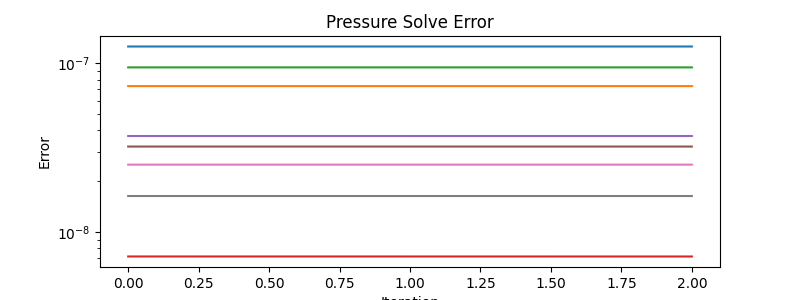

In [11]:
fig, axis = plt.subplots(1, 1, figsize=(8, 3), squeeze=False)

for i, (errors, pressures) in enumerate(trajectories):
    axis[0,0].plot(errors, label=f"Trajectory {i+1}")
axis[0,0].set_title("Pressure Solve Error")
axis[0,0].set_xlabel("Iteration")
axis[0,0].set_ylabel("Error")
axis[0,0].set_yscale('log')

In [12]:

markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B":runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            # flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            # vMin = 0.99,
            # vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)


RFBOutputContext()

In [13]:
config.dt = 1e-3
runningState = compressibleSystem.initializeNewState()
# runningState.state.positions = shuffleParticles(runningState.state, config, schemeConfig, 0, jitterAmount = 0.01)

runningState.state.velocities = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
adjacency = None

trajectories = []
adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = adjacency,
    verbose = False)
rhoInit = computeDensities(runningState.state, config, schemeConfig, adjacency)

# schemeConfig.solverConfig.pressureSolver.tolerance = 1e-5


for i in (tq:=tqdm(range(128))):

    adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = adjacency,
        verbose = False)
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, adjacency)
    runningState.state.pressures[:] = 0.0

    a_p, pressureB, errors, pressures = solveIncompressible(
            particles = runningState.state,
            config = config,
            schemeConfig = schemeConfig,
            adjacency = adjacency,
            dvdt = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype),
            dt = config.dt
    )
    trajectories.append((errors,pressures))

    dx = config.dt**2 * a_p
    print(f"Position update: mean: {dx.mean().cpu().item():.6g}, min: {dx.min().cpu().item():.6g}, max: {dx.max().cpu().item():.6g}")
    tq.set_description(f"Step {i+1}/{128}, iters: {len(errors)}, error: {errors[0]:.6g} -> {errors[-1]:.6g}, pressure min/max/mean: {pressures[-1]}")

    # runningState.state.velocities = runningState.state.velocities + config.dt * a_p
    runningState.state.positions = runningState.state.positions + config.dt * config.dt * a_p

schemeConfig.solverConfig.pressureSolver.tolerance = 5e-4

  0%|          | 0/128 [00:00<?, ?it/s]

Position update: mean: 2.72005e-15, min: -1.45593e-07, max: 1.54314e-07
Position update: mean: -8.88178e-16, min: -1.4535e-07, max: 1.54279e-07
Position update: mean: -5.9952e-15, min: -2.52248e-07, max: 2.5556e-07
Position update: mean: -6.10623e-16, min: -1.61236e-07, max: 1.6426e-07
Position update: mean: -2.22045e-15, min: -2.15114e-07, max: 2.15451e-07
Position update: mean: -2.77556e-15, min: -2.06914e-07, max: 2.31356e-07
Position update: mean: -3.10862e-15, min: -2.07066e-07, max: 2.1838e-07
Position update: mean: -3.27516e-15, min: -2.49523e-07, max: 2.60941e-07
Position update: mean: -3.27516e-15, min: -1.83099e-07, max: 2.02196e-07
Position update: mean: -3.38618e-15, min: -2.13295e-07, max: 2.34852e-07
Position update: mean: -2.27596e-15, min: -1.95245e-07, max: 1.86791e-07
Position update: mean: -3.10862e-15, min: -2.06137e-07, max: 2.00185e-07
Position update: mean: -2.77556e-15, min: -2.24624e-07, max: 2.1101e-07
Position update: mean: -2.9976e-15, min: -2.2829e-07, max:

Text(0, 0.5, 'Error')

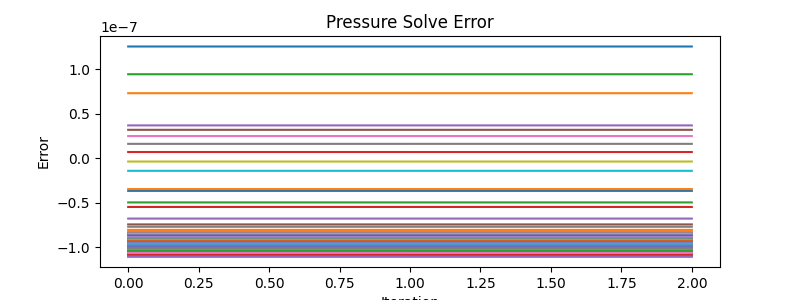

In [14]:
fig, axis = plt.subplots(1, 1, figsize=(8, 3), squeeze=False)

for i, (errors, pressures) in enumerate(trajectories):
    axis[0,0].plot(errors, label=f"Trajectory {i+1}")
axis[0,0].set_title("Pressure Solve Error")
axis[0,0].set_xlabel("Iteration")
axis[0,0].set_ylabel("Error")
# axis[0,0].set_yscale('log')

In [15]:
compressibleSystem.state.positions = runningState.state.positions.clone()
compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv *  compressibleSystem.state.positions[:,1] + phaseShift_y)
compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * compressibleSystem.state.positions[:,1] + phaseShift_y)


In [16]:

hMin = compressibleSystem.state.supports.min().cpu().item()
vMax = torch.linalg.norm(compressibleSystem.state.velocities, dim = -1).max().cpu().item()
velocityRatio = hMin / vMax
cflNumber = config.dt / velocityRatio


print(f"Initial hMin: {hMin:.6g}, vMax: {vMax:.6g}, CFL number: {cflNumber:.6g}")


Initial hMin: 0.19635, vMax: 0.999398, CFL number: 0.00508989


In [17]:
schemeConfig.diffusionParams.inviscid = False
schemeConfig.diffusionParams.viscidNu = 0.01
schemeConfig.shiftProperties.active = False

In [18]:
runningState = compressibleSystem.initializeNewState()

runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, None)
# runningState.state.densities[:] = schemeConfig.fluid.restDensity

print(f"Initial densities: mean: {runningState.state.densities.mean().cpu().item():.6g}, min: {runningState.state.densities.min().cpu().item():.6g}, max: {runningState.state.densities.max().cpu().item():.6g}")

for i in range(2):
    print('-' * 80)
    print(f"Step {i+1}/{2}, t={runningState.t:.6g}, dt={config.dt:.6g}")

    result = integrator.function(
        state = runningState,
        f = dfsph_step,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )

    runningState = result.state
    errors, pressures = result.stages[0].aux[-1]
    numIters = len(errors)
    print(f"First pressure solve: error: {errors[0]:.6g} -> {errors[-1]:.6g}, iterations: {numIters}")
    errors, pressures = result.stages[-1].aux[-2]
    numIters = len(errors)
    print(f"Final pressure solve: error: {errors[0]:.6g} -> {errors[-1]:.6g}, iterations: {numIters}")
    errors_incomp, pressures_incomp = result.stages[-1].aux[-1]
    numIters_incomp = len(errors_incomp)
    print(f"Final incompressible pressure solve: error: {errors_incomp[0]:.6g} -> {errors_incomp[-1]:.6g}, iterations: {numIters_incomp}")

Initial densities: mean: 1, min: 0.999995, max: 1
--------------------------------------------------------------------------------
Step 1/2, t=0, dt=0.001
Module warpSPH.modules.deltaSPH.wp_viscosityDelta b587ee0 load on device 'cuda:0' took 3.25 ms  (cached)
Finalizing state at t=0.002, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompressible Error: -4.234e-07->-4.234e-07
Module sphWarpCore.operations.wp_gradient 6783d82 load on device 'cuda:0' took 7.36 ms  (cached)
First pressure solve: error: 1.87735e-05 -> 1.583e-05, iterations: 3
Final pressure solve: error: 0.000390023 -> 0.000366941, iterations: 3
Final incompressible pressure solve: error: -4.23366e-07 -> -4.23369e-07, iterations: 3
--------------------------------------------------------------------------------
Step 2/2, t=0.001, dt=0.001
Finalizing state at t=0.003, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompressible Error: -4.412e-07->-4.412e-07
First pressure solve: error: 0.000730653 -> 0.0006

In [19]:
runningState.state.pressures.min(), runningState.state.pressures.max(), runningState.state.pressures.mean()

(tensor(-0.0728, device='cuda:0'),
 tensor(0.0725, device='cuda:0'),
 tensor(6.4028e-10, device='cuda:0'))

In [20]:

markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B":runningState.state.pressures,# - runningState.state.pressures.median(),
    },
    plotOptions = {
        "A": PlottingOptions(
            # colorMap = DivergingColorMap.RdBu,
            # flipColorMap=True,
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "densities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "pressures",
            # vMin = 0.99,
            # vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = f"Taylor Green Vortex (Incompressible), t={runningState.t:.3f}s ptcls={runningState.state.positions.shape[0]}, dt={config.dt:.3g}s\nDivergence Free error={errors[0]:.4g}->{errors_incomp[-1]:.4g} after {numIters} iterations, Incompressible error={errors_incomp[0]:.4g}->{errors_incomp[-1]:.4g} after {numIters_incomp} iterations",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)
imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)




RFBOutputContext()

In [21]:
meanRhoError = (runningState.state.densities - schemeConfig.fluid.restDensity).abs().mean().cpu().item()
print(f"Mean dePnsity error: {meanRhoError:.6g}")

Mean dePnsity error: 1.97229e-06


In [22]:
schemeConfig.diffusionParams.inviscid = False
schemeConfig.diffusionParams.viscidNu = 0.01
schemeConfig.shiftProperties.active = False

In [23]:
config.dt = 1e-3

t_limit = 2.0
nSteps = int(t_limit / config.dt)
# nSteps = 7

runningState = compressibleSystem.initializeNewState()

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = dfsph_step,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    # runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, None)
    # print(f'Computing with verletScale = 1.0')
    # adjacency = buildVerletList(
    #         runningState.state, 
    #         config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    #         priorNeighborhood = None,
    #         verbose = False)
    # numNeighbors = adjacency.numNeighbors
    # print(f'{i}: Min neighbors: {numNeighbors.min().cpu().item()}, Max neighbors: {numNeighbors.max().cpu().item()}, Mean neighbors: {numNeighbors.float().mean().cpu().item()}')
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, None)

    # print(f'{i}: Min Density [no adj]: {runningState.state.densities.min().cpu().item()}, Max Density: {runningState.state.densities.max().cpu().item()}, Mean Density: {runningState.state.densities.mean().cpu().item()}')

    # densitiesAdj = computeDensities(runningState.state, config, schemeConfig, adjacency)

    # print(f'Computing with verletScale = {config.verletScale}')
    # adjacency2 = buildVerletList(
    #         runningState.state, 
    #         config.domain, verletScale = config.verletScale, supportMode = SupportScheme.SuperSymmetric,
    #         priorNeighborhood = None,
    #         verbose = False)
    # numNeighbors = adjacency2.numNeighbors
    # densitiesAdj2 = computeDensities(runningState.state, config, schemeConfig, adjacency2)
    # print(f'{i}: Min neighbors: {numNeighbors.min().cpu().item()}, Max neighbors: {numNeighbors.max().cpu().item()}, Mean neighbors: {numNeighbors.float().mean().cpu().item()}')

    # diff = torch.abs(densitiesAdj - densitiesAdj2)
    # maxDiff = diff.max().cpu().item()
    # meanDiff = diff.mean().cpu().item()
    # print(f'{i}: Min Density [adj]: {densitiesAdj.min().cpu().item()}, Max Density: {densitiesAdj.max().cpu().item()}, Mean Density: {densitiesAdj.mean().cpu().item()}, Max Diff: {maxDiff:.6g}, Mean Diff: {meanDiff:.6g}')

    # diffNumNeighbors = torch.abs(adjacency.numNeighbors - adjacency2.numNeighbors)
    # maxDiffNeighbors = diffNumNeighbors.max().cpu().item()
    # meanDiffNeighbors = diffNumNeighbors.float().mean().cpu().item()
    # print(f'{i}: Min Neighbors [adj]: {adjacency.numNeighbors.min().cpu().item()}, Max Neighbors: {adjacency.numNeighbors.max().cpu().item()}, Mean Neighbors: {adjacency.numNeighbors.float().mean().cpu().item()}, Max Diff Neighbors: {maxDiffNeighbors:.6g}, Mean Diff Neighbors: {meanDiffNeighbors:.6g}')

    # if maxDiff > 1e-3:
    #     print(f"Warning: Density difference between adjacency computations exceeds threshold at step {i}. Max Diff: {maxDiff:.6g}, Mean Diff: {meanDiff:.6g}")
    #     break

    # print(f'{i}: Min Density [adj]: {runningState.state.densities.min().cpu().item()}, Max Density: {runningState.state.densities.max().cpu().item()}, Mean Density: {runningState.state.densities.mean().cpu().item()}')

    errors, pressures = result.stages[-1].aux[-2]
    numIters = len(errors)
    errors_incomp, pressures_incomp = result.stages[-1].aux[-1]
    numIters_incomp = len(errors_incomp)
    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                # "A": runningState.state.densities,
                "B": runningState.state.pressures - runningState.state.pressures.mean(),
                # "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)


        plotter.updateTitle(f'Taylor Green Vortex (Incompressible), t={(i+1)*config.dt:.3f}s ptcls={runningState.state.positions.shape[0]}, dt={config.dt:.3g}s\nDivergence Free error={errors[0]:.4g}->{errors[-1]:.4g} after {numIters} iterations, Incompressible error={errors_incomp[0]:.4g}->{errors_incomp[-1]:.4g} after {numIters_incomp} iterations')
    # break
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms div free {errors[0]:.4g}->{errors[-1]:.4g} in {numIters} iters, incompressible {errors_incomp[0]:.4g}->{errors_incomp[-1]:.4g} in {numIters_incomp} iters")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/2000 [00:00<?, ?it/s]

Finalizing state at t=0.002, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompressible Error: -4.234e-07->-4.234e-07
Finalizing state at t=0.003, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompressible Error: -4.412e-07->-4.412e-07
Finalizing state at t=0.004, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompressible Error: -4.279e-07->-4.279e-07
Finalizing state at t=0.005, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompressible Error: -3.504e-07->-3.505e-07
Finalizing state at t=0.006, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompressible Error: -3.884e-07->-3.885e-07
Finalizing state at t=0.007, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompressible Error: -3.43e-07->-3.43e-07
Finalizing state at t=0.008, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompressible Error: -3.013e-07->-3.013e-07
Finalizing state at t=0.009000000000000001, dt=0.001, with 16384 particles.
Solver Iterations: 3, Incompre

In [ ]:
rho = computeDensities(runningState.state, config, schemeConfig, None)
meanRhoError = (rho - schemeConfig.fluid.restDensity).abs().mean().cpu().item()
print(f"Mean density error: {meanRhoError:.6g}")

In [43]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 60 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

'export/tgv_incompressible/output.mp4'

In [25]:
runningState.state.densities.min(), runningState.state.densities.max(), runningState.state.densities.mean()

(tensor(0.9977, device='cuda:0'),
 tensor(1.0048, device='cuda:0'),
 tensor(1.0012, device='cuda:0'))

Something to note here is that the effective viscosity we measure here will be about half of the defined viscosity. This is an effect of the classic monaghan viscosity that only applies the viscosity to particles approaching each other. This is only true for (approximately) half the particles, thus we measure a viscosity that is half as well.

In [24]:
ts = np.arange(len(kes)) * config.dt#.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])
E_k0 = kineticEnergy[0]

# Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
mask = (ts > 0) & (kineticEnergy > 0)
slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
nu_eff = -slope / (4 * ktgv**2)
print(f"Estimated effective viscosity: {nu_eff:.6g}, actual viscosity: {schemeConfig.diffusionParams.viscidNu
:.6g}, diff: {abs(nu_eff - schemeConfig.diffusionParams.viscidNu
):.6g}")

Estimated effective viscosity: 0.00608849, actual viscosity: 0.01, diff: 0.00391151


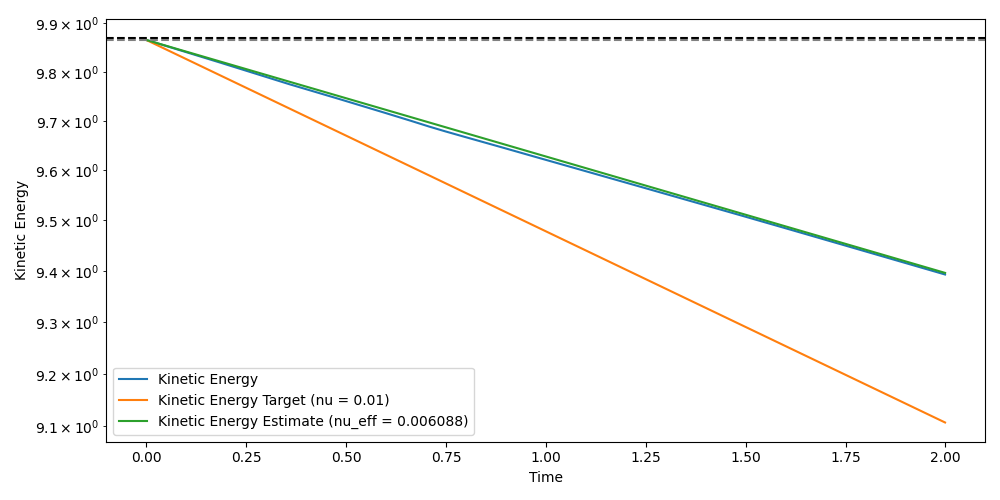

In [25]:
fig, axis = plt.subplots(1, 1, figsize=(10, 5), squeeze=False)

ts = np.arange(len(kes)) * config.dt#.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])

nu = schemeConfig.diffusionParams.viscidNu

Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2
ke0 = E_k0
# For u ~ exp(-2*nu*k_mode^2*t), kinetic energy decays as exp(-4*nu*k_mode^2*t).
E_kestimate = ke0 * np.exp(-4 * ts * (ktgv**2) * nu_eff)
E_ktarget = ke0 * np.exp(-4 * ts * (ktgv**2) * nu)

axis[0,0].plot(ts, kineticEnergy, label='Kinetic Energy')
axis[0,0].plot(ts, E_ktarget, label=f'Kinetic Energy Target (nu = {nu:.4g})')
axis[0,0].plot(ts, E_kestimate, label=f'Kinetic Energy Estimate (nu_eff = {nu_eff:.4g})')
axis[0,0].set_xlabel('Time')
axis[0,0].set_ylabel('Kinetic Energy')
axis[0,0].legend()

axis[0,0].axhline(Ek0_theoretical, color='black', linestyle='--', label='Theoretical Initial Kinetic Energy')
axis[0,0].axhline(ke0, color='gray', linestyle='--', label='Initial Kinetic Energy from Simulation')

axis[0,0].set_yscale('log')

fig.tight_layout()

In [ ]:
# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'kineticEnergy': kineticEnergy,
#     'thermalEnergy': thermalEnergy,
#     'totalEnergy': totalEnergy,
#     'frame_num': i,
# }))

In [ ]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

We can run a convergence test to see how the viscosity scales as well:

In [ ]:
nu_tests = np.logspace(-1, -5, base=10, num=10)
test_data = []

for nu in tqdm(nu_tests, desc="Testing viscosities", leave=False):
    t_limit = 2.0
    nSteps = int(t_limit / config.dt)

    runningState = compressibleSystem.initializeNewState()
    schemeConfig.diffusionParams.viscidNu = nu

    kes = []
    priorStep = None
    for i in (tq := tqdm(range(nSteps), leave = False)):
        begin = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        begin.record()
        result = integrator.function(
            state = runningState,
            f = fn,
            dt = config.dt,  
            config = config,
            schemeConfig = schemeConfig,
            verbose = False,
            priorStep = priorStep
        )
        kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
        # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
        end.record()
        torch.cuda.synchronize()
        priorStep = result.stages[-1]
        timing = begin.elapsed_time(end)

        runningState = result.state

        if i % 60 == 0 and i > 0:
            plotter.updateQuantities(
                {
                    "A": runningState.state.velocities,
                    "B": runningState.state.densities,
                },
                newParticleState = runningState.state,
            )
            
        maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
        tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
        # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
        # break
        if torch.any(torch.isnan(runningState.state.velocities)):
            print("NaN detected in velocities, stopping simulation.")
            breakts = np.arange(len(kes)) * config.dt.cpu().item()
    kineticEnergy = np.array([ke.cpu().item() for ke in kes])
    E_k0 = kineticEnergy[0]

    # Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
    mask = (ts > 0) & (kineticEnergy > 0)
    slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
    nu_eff = -slope / (4 * ktgv**2)

    test_data.append({
        'nu': nu,
        'nu_eff': nu_eff,
        'nu_diff': abs(nu_eff - nu),
        'nu_rel_diff': abs(nu_eff - nu) / nu,
        'E_k0': E_k0,
        'kineticEnergy': kineticEnergy,
        'ts': ts,
    })


In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)

nus = np.array([data['nu'] for data in test_data])
nu_effs = np.array([data['nu_eff'] for data in test_data])
axis[0,0].loglog(nus, nu_effs, marker='o', label='nu_eff')
axis[0,0].loglog(nus, nus, marker='o', label='nu')
axis[0,0].set_xlabel('Input Viscosity (nu)')
axis[0,0].set_ylabel('Effective Viscosity (nu_eff)')
axis[0,0].set_title('Effective Viscosity vs Input Viscosity')
axis[0,0].legend()

axis[0,1].loglog(nus, nu_effs / nus, marker='o')
axis[0,1].set_xlabel('Input Viscosity (nu)')
axis[0,1].set_ylabel('nu_eff / nu')
axis[0,1].set_title('Ratio of Effective to Input Viscosity')

fig.tight_layout()

fig.savefig('nu_eff_vs_nu.png', dpi=300)
